In [945]:
pharma_cluster = [
"Calvis Sciences",
"Calvos Genomics",
"Frelis Genomics",
"Grevel Diagnostics",
"Grevon Biotech",
"Jorvix Diagnostics",
"Krevum Pharmaceuticals",
"Myrnon Therapeutics",
"Nerval Biopharma",
"Relvos Biosciences",
"Wyrnik Sciences",
"Xelvol Biotech",
"Yorvov Pharmaceuticals",
"Zelvix Therapeutics",
"Zelvon Biosciences",
"Zrovum Biopharma"]

energy_cluster = [
"Jorvis Fuels",
"Kelvik Power",
"Kelvos Resources",
"Nerven Grid",
"Nolvol Resources",
"Orevex Renewables",
"Orevov Solutions",
"Plevep Power",
"Plevik Energy",
"Relvon Fuels",
"Strynal Industries",
"Ulvon Renewables",
"Urvel Grid",
"Wyrnor Solutions",
"Zelval Energy",
"Zrovex Industries"]

commerce_cluster = [
"Arnik Commerce",
"Arnos Marketplace",
"Crevol Retail",
"Frelex Outlets",
"Halvav Brands",
"Holtar Stores",
"Ixenis Outlets",
"Jorval Trading",
"Joval Brands",
"Nolvav Commerce",
"Orevar Marketplace",
"Pleven Trading",
"Talvyn Goods",
"Varvov Retail",
"Xovep Stores",
"Xovol Goods"]

money_cluster = [
"Creven Securities",
"Ervan Capital",
"Halven Investments",
"Halvix Holdings",
"Holtum Asset",
"Ilval Financial",
"Jorvyl Securities",
"Jovik Asset",
"Krevan Investments",
"Plevum Partners",
"Plevyl Advisors",
"Talvix Holdings",
"Wrelal Financial",
"Yorval Partners",
"Zelvel Capital",
"Zrovov Advisors"]

hardware_cluster = [
"Brevep Systems",
"Brevon Microchips",
"Crevex Labs",
"Dralol Computing",
"Frelol Software",
"Halvax Networks",
"Ixenix Technologies",
"Jovor Networks",
"Myrnep Technologies",
"Nolvis Devices",
"Prynis Systems",
"Relvan Software",
"Talvep Computing",
"Ulvyn Microchips",
"Volval Devices",
"Yorven Labs"
]

clusters = [pharma_cluster, energy_cluster, commerce_cluster, money_cluster, hardware_cluster]

In [946]:
import pandas as pd
import numpy as np

bars_df = pd.read_parquet("../data/bars_seen_train.parquet")
unseen_bars_df = pd.read_parquet("../data/bars_unseen_train.parquet")
sentiment_df = pd.read_csv("../anna/headline_stats_seen_train.csv")
headlines_df_seen = pd.read_parquet("../data/headlines_seen_train.parquet")
headlines_df_unseen = pd.read_parquet("../data/headlines_unseen_train.parquet")

print(sentiment_df.head())
print(bars_df.head())

cluster_labels = {
    "pharma": pharma_cluster,
    "energy": energy_cluster,
    "commerce": commerce_cluster,
    "money": money_cluster,
    "hardware": hardware_cluster,
}

company_to_cluster = {
    company: label
    for label, companies in cluster_labels.items()
    for company in companies
}

# Build a regex pattern from all company names
import re

pattern = "|".join(re.escape(name) for name in company_to_cluster)

def assign_cluster(headline):
    match = re.search(pattern, headline)
    if match:
        return company_to_cluster[match.group(0)]
    return None

   session                headline  bar_ix decided_label  prob_positive  \
0        0      Relvos Biosciences       6       neutral       0.387032   
1        0       Orevex Renewables      12      positive       0.948091   
2        0      Relvos Biosciences      14       neutral       0.061307   
3        0         Calvis Sciences      20      positive       0.945060   
4        0  Yorvov Pharmaceuticals      22      positive       0.947761   

   prob_negative  prob_neutral  linear_score  polarity_score  cluster  
0       0.013454      0.599514      0.373578        0.932811        0  
1       0.012295      0.039614      0.935795        0.974395        1  
2       0.040272      0.898421      0.021034        0.207074        0  
3       0.010088      0.044852      0.934971        0.978876        0  
4       0.012083      0.040155      0.935678        0.974823        0  
   bar_ix  session  open    high     low   close
0       0        0   1.0  1.0029  0.9986  0.9999
1       0        1 

Nolvav Commerce secures $180M contract with a multinational manufacturer
3
Frelex Outlets secures $180M contract with a leading cloud platform
5
Kelvos Resources delays product launch in automated logistics segment
10
Nolvav Commerce sees 5% margin improvement in latest quarter
10
Kelvos Resources faces regulatory review of cloud infrastructure practices
12
Nolvav Commerce secures $400M contract with a leading cloud platform
12
Frelex Outlets secures $75M contract with an international consortium
24
Holtar Stores names new head of supply chain optimization division
28
Holtar Stores explores strategic alternatives for renewable storage unit
37
Holtar Stores begins scheduled maintenance of precision manufacturing systems
40
Holtar Stores names new head of automated logistics division
48
Nolvav Commerce delays product launch in process automation segment
57
hello
Nolvav Commerce secures $120M contract with a multinational manufacturer
61
hello
Kelvos Resources misses quarterly revenue est

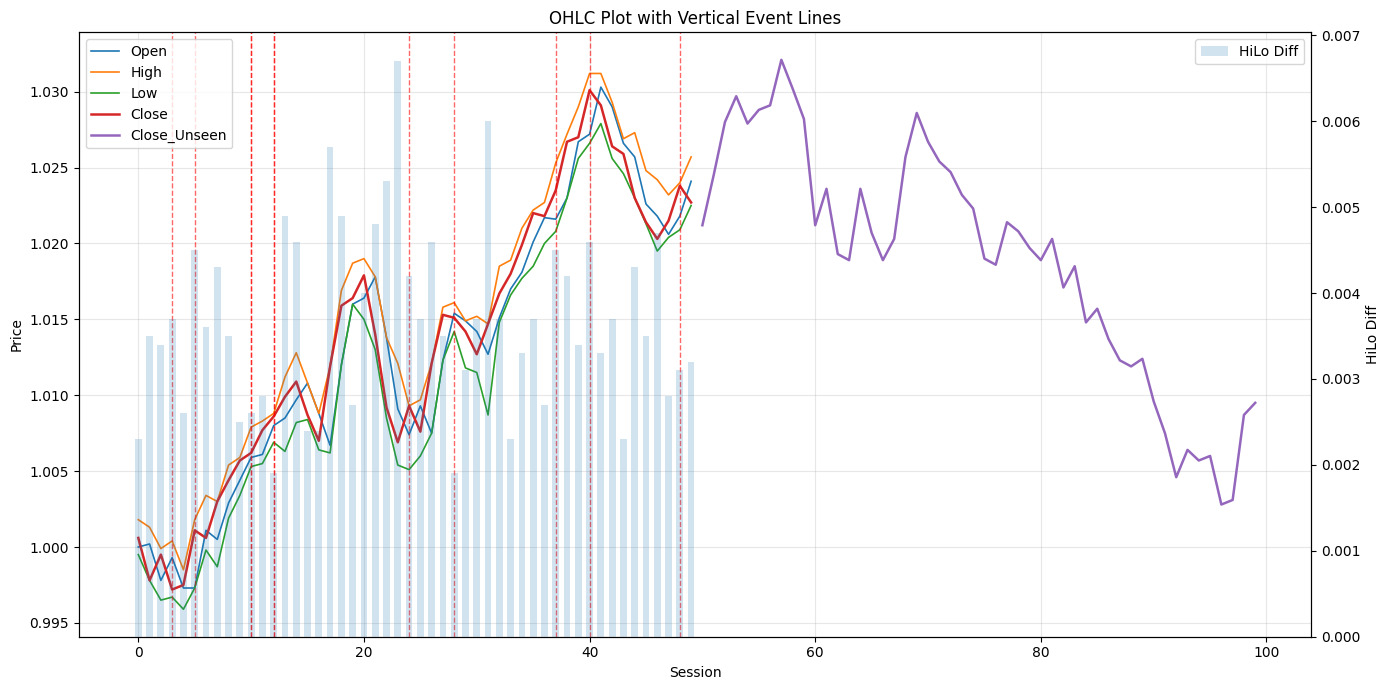

In [ ]:
session_of_interest = 67

import pandas as pd
import matplotlib.pyplot as plt

# df  = main dataframe with OHLC data
# df2 = second dataframe containing bar_ix values where vertical lines should be drawn

# Example:
# df2 = pd.DataFrame({"bar_ix": [5, 12, 18, 33, 41]})

df = bars_df[bars_df["session"] == session_of_interest]
df["hilo_diff"] = df["high"] - df["low"]
df2 = sentiment_df[sentiment_df["session"] == session_of_interest]
df_unseen = unseen_bars_df[unseen_bars_df["session"] == session_of_interest]
headlines_df_seen = headlines_df_seen[headlines_df_seen["session"] == session_of_interest]
headlines_df_seen["cluster"] = headlines_df_seen["headline"].apply(assign_cluster)
# headlines_df_seen = headlines_df_seen[headlines_df_seen["headline"].str.contains("breakthrough")]
headlines_df_unseen = headlines_df_unseen[headlines_df_unseen["session"] == session_of_interest]
# print(headlines_df_seen)

for idx, row in headlines_df_seen.iterrows():
    print(row.headline)
    print(row.bar_ix)

for idx, row in headlines_df_unseen.iterrows():
    print(row.headline)
    print(row.bar_ix)
    print("hello")
# print(headlines_df_unseen)

fig, ax1 = plt.subplots(figsize=(14, 7))

# Main OHLC lines
ax1.plot(df["bar_ix"], df["open"],  label="Open", linewidth=1.2)
ax1.plot(df["bar_ix"], df["high"],  label="High", linewidth=1.2)
ax1.plot(df["bar_ix"], df["low"],   label="Low", linewidth=1.2)
ax1.plot(df["bar_ix"], df["close"], label="Close", linewidth=1.8)
ax1.plot(df_unseen["bar_ix"], df_unseen["close"], label="Close_Unseen", linewidth=1.8)

# Add vertical lines at bar_ix positions from df2
for x in df2["bar_ix"]:
    ax1.axvline(x=x, linestyle="--", linewidth=1, alpha=0.6, color="red")

# Secondary axis for hilo_diff
ax2 = ax1.twinx()
ax2.bar(df["bar_ix"], df["hilo_diff"], alpha=0.2, width=0.6, label="HiLo Diff")

# Labels
ax1.set_xlabel("Session")
ax1.set_ylabel("Price")
ax2.set_ylabel("HiLo Diff")

# Title
plt.title("OHLC Plot with Vertical Event Lines")

# Legend
ax1.legend(loc="upper left")
ax2.legend(loc="upper right")

# Grid
ax1.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

In [948]:
def do_single_session(session_of_interest=2):
    df = bars_df[bars_df["session"] == session_of_interest].copy()

    df["hilo_diff"] = df["high"] - df["low"]

    df2 = sentiment_df[sentiment_df["session"] == session_of_interest].copy()
    df2["cluster"] = df2["headline"].apply(assign_cluster)
    df2["total_sentiment"] = abs(df2["prob_positive"] - df2["prob_negative"]) / (df2["prob_positive"] - df2["prob_negative"]) * np.sqrt(abs(df2["prob_positive"] - df2["prob_negative"])) * (df2["bar_ix"])
    

    result = pd.merge(df, df2, on="bar_ix", how="inner")

    only_volatility = result[["bar_ix","headline", "total_sentiment", "cluster", "hilo_diff", "prob_positive", "prob_negative", "prob_neutral"]].sort_values(
        by="bar_ix",
        ascending=False   # highest first
    )

    only_volatility["some_metric"] = only_volatility["hilo_diff"] / only_volatility["prob_neutral"]
    identify_cluster = only_volatility.sort_values(by="some_metric", ascending=False).head(3)
    print("some_metric", identify_cluster)
    total_s = identify_cluster.groupby("cluster")["total_sentiment"].sum()
    print("direction", total_s)

    # candidate_a = only_volatility[only_volatility["headline"] == "Zrovex Industries"]
    # candidate_b = only_volatility[only_volatility["headline"] == "Jorvis Fuels"]
    return (0, 0)
    return candidate_a, candidate_b

In [949]:
a, b = do_single_session(session_of_interest=session_of_interest)

some_metric    bar_ix         headline  total_sentiment   cluster  hilo_diff  \
1       5   Frelex Outlets         4.844765  commerce     0.0045   
3      10  Nolvav Commerce         9.684651  commerce     0.0026   
6      24   Frelex Outlets        23.156183  commerce     0.0042   

   prob_positive  prob_negative  prob_neutral  some_metric  
1       0.951847       0.012977      0.035176     0.127929  
3       0.957210       0.019286      0.023504     0.110618  
6       0.942562       0.011644      0.045795     0.091713  
direction cluster
commerce    37.685599
Name: total_sentiment, dtype: float64


In [950]:
a

0

In [951]:
b

0

In [952]:
def identify_firm(session_of_interest=2):
    price_df = bars_df[bars_df["session"] == session_of_interest].copy().copy()
    news_df = sentiment_df[sentiment_df["session"] == session_of_interest].copy()
    news_df = news_df.copy()
    news_df["company"] = news_df["headline"]

    # ---------------------------------------------------------
    # STEP 2: Convert sentiment probabilities into one score
    # positive = +1
    # negative = -1
    # neutral = 0
    # ---------------------------------------------------------
    news_df["sentiment_score"] = (
        news_df["prob_positive"] - news_df["prob_negative"]
    )

    print("SENTIMENT:",news_df["sentiment_score"].sum())

    # ---------------------------------------------------------
    # STEP 3: Aggregate sentiment by bar_ix and company
    # ---------------------------------------------------------
    sentiment = (
        news_df.groupby(["company", "bar_ix"], as_index=False)
        .agg(sentiment_score=("sentiment_score", "mean"))
    )

    

results_df = identify_firm(session_of_interest=session_of_interest)

SENTIMENT: 3.6189756663516164


In [953]:
firm_of_interest = results_df["company"][0]
print(firm_of_interest)

TypeError: 'NoneType' object is not subscriptable

In [ ]:
def only_headlines_sentiment(session_of_interest, firm_of_interest):
    price_df = bars_df[bars_df["session"] == session_of_interest].copy().copy()
    news_df = sentiment_df[sentiment_df["session"] == session_of_interest].copy()
    news_df = news_df[news_df["headline"] == firm_of_interest]
    news_df = news_df.copy()
    print(news_df)
    return news_df
    
filterned_news_df = only_headlines_sentiment(session_of_interest, firm_of_interest)

   session                headline  bar_ix decided_label  prob_positive  \
4        0  Yorvov Pharmaceuticals      22      positive       0.947761   
8        0  Yorvov Pharmaceuticals      44      negative       0.026838   

   prob_negative  prob_neutral  linear_score  polarity_score  cluster  
4       0.012083      0.040155      0.935678        0.974823        0  
8       0.947266      0.025896     -0.920428       -0.944897        0  


In [ ]:
def get_sizing(filterned_news_df):

    DECAY_LAMBDA = 0.15     # staleness decay rate
    THRESHOLD = 0.05        # no-trade zone
    MAX_LEVERAGE = 2.0      # cap position size

    # -----------------------------
    # 2. SORT DATA
    # -----------------------------
    df = filterned_news_df.sort_values(["session", "bar_ix"])

    # -----------------------------
    # 3. COMPUTE STALENESS DECAY
    # -----------------------------
    # within each session, compute time since most recent bar
    df["age"] = df.groupby("session")["bar_ix"].transform(
        lambda x: 50 - x
    )

    df["decay"] = np.exp(-DECAY_LAMBDA * df["age"])

    # -----------------------------
    # 4. EFFECTIVE SENTIMENT SIGNAL
    # -----------------------------
    df["effective_signal"] = df["linear_score"] * df["decay"]

    # -----------------------------
    # 5. AGGREGATE PER BAR (important)
    # -----------------------------
    agg = (
        df.groupby(["session", "bar_ix"], as_index=False)
        .agg({
            "effective_signal": "sum",
            "linear_score": "mean",
            "decay": "mean"
        })
    )

    # -----------------------------
    # 6. VOLATILITY PROXY
    # -----------------------------
    # simple rolling std of signal per session
    agg["volatility"] = (
        agg.groupby("session")["effective_signal"]
        .transform(lambda x: x.rolling(5, min_periods=1).std().fillna(1e-3))
    )

    # -----------------------------
    # 7. NORMALIZED TRADE SIGNAL
    # -----------------------------
    agg["raw_signal"] = agg["effective_signal"] / agg["volatility"]

    # -----------------------------
    # 8. POSITION SIZING FUNCTION
    # -----------------------------
    def size_position(x):
        if abs(x) < THRESHOLD:
            return 0.0
        return np.clip(x, -MAX_LEVERAGE, MAX_LEVERAGE)

    agg["position"] = agg["raw_signal"].apply(size_position)

    # -----------------------------
    # 9. TRADE DIRECTION
    # -----------------------------
    agg["direction"] = np.sign(agg["position"])

    # -----------------------------
    # 10. FINAL OUTPUT
    # -----------------------------
    result = agg[[
        "session",
        "bar_ix",
        "effective_signal",
        "raw_signal",
        "position",
        "direction"
    ]]

    print(result.head())
    return result["effective_signal"].sum()

print(round(get_sizing(filterned_news_df), 3))

   session  bar_ix  effective_signal  raw_signal  position  direction
0        0      22          0.014031   14.031035  2.000000        1.0
1        0      44         -0.374218   -1.363105 -1.363105       -1.0
-0.36
